# Lab 1: Adversarial Attacks on Neural Networks

Aim of this lab: Implement a gradient-based attack (FGSM or PGD) on a provided classifier, measure success rate across perturbation budgets, and discuss transferability.

The examples use the [CleverHans](https://github.com/cleverhans-lab/cleverhans) library to:

1. Benchmark neural networks for vulnerability against specific attack types
2. Craft adversarial examples

In [1]:
pip install -r requirements.txt

You should consider upgrading via the '/Users/jonasson/.pyenv/versions/datascience-in-prod/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Imports
import os
from easydict import EasyDict
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
import torchvision
import datasets
import matplotlib.pyplot as plt

from cleverhans.torch.attacks.fast_gradient_method import fast_gradient_method
from cleverhans.torch.attacks.projected_gradient_descent import projected_gradient_descent

/Users/jonasson/.pyenv/versions/datascience-in-prod/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Data Loading

In [3]:
def ld_mnist():
    train_transforms = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])
    test_transforms = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])

    # Load MNIST dataset
    train_dataset = torchvision.datasets.MNIST(root="/tmp/data", train = True, download = True, transform=train_transforms)
    test_dataset = torchvision.datasets.MNIST(root="/tmp/data", train=False, download = True, transform=test_transforms)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)
    
    return EasyDict(train=train_loader, test=test_loader)

In [4]:
data = ld_mnist()
print("Data loaded.")

Data loaded.


## The CNN Models

In the following section we will define the machine learning models we will attack. We use convolutional neural networks (CNNs), an architecture that is commonly used for image data. A fully-connected neural network will treat a 28x28 image as 784 features, this requires a large number of parameters and loses the spatial structure of the image. Convolutional layers apply learned filters on images. These filters reduce the number of parameters needed and exploits local spatial structure. If we stack many of these learned layers on top of each other we can extract patterns such as edges from the image before classification.  

In [5]:
class Basic_CNN(torch.nn.Module):
    """Target CNN architecture."""

    def __init__(self, in_channels=1, p_drop=0.0): # 3 conv layers
        super(Basic_CNN, self).__init__()               # Kernel sizes
        self.conv1 = nn.Conv2d(in_channels, 64, 8, 1)   # (28x28) --> (21x21)
        self.conv2 = nn.Conv2d(64, 128, 6, 2)           # (21x21) --> (8x8)
        self.conv3 = nn.Conv2d(128, 128, 5, 1)          # (8x8) --> (4x4)
        self.dropout = nn.Dropout(p=p_drop)
        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x
    
# ---------------------------------

class Target_CNN(torch.nn.Module): # 4 conv layers
    """Basic CNN architecture."""

    def __init__(self, in_channels=1, p_drop=0.0):
        super(Target_CNN, self).__init__()              # Kernel sizes
        self.conv1 = nn.Conv2d(in_channels, 32, 5, 1)  # (28x28 -> 24x24)
        self.conv2 = nn.Conv2d(32, 64, 3, 2)           # (24x24 -> 11x11)
        self.conv3 = nn.Conv2d(64, 128, 3, 2)          # (11x11 -> 5x5)
        self.conv4 = nn.Conv2d(128, 128, 3, 1)         # (5x5 -> 3x3)
        self.dropout = nn.Dropout(p=p_drop)
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [6]:
import torch.optim as optim
from tqdm import tqdm

def train_model(model, train_loader, test_loader, epochs=5, lr=0.001, device="cpu"):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}: Loss = {running_loss/len(train_loader):.4f}")

        acc = evaluate_model(model, test_loader, device)
        print(f"Test Accuracy after epoch {epoch+1}: {acc:.2f}%")

    return model


def evaluate_model(model, test_loader, device="cpu"):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


In [7]:
# Only used while training the models for the first time
to_train = False

to_train = not (os.path.exists('basic_cnn.pth') or os.path.exists('target_cnn.pth'))

if to_train:
    print("\nTraining Basic_CNN...")
    basic_cnn = Basic_CNN()
    basic_cnn = train_model(basic_cnn, data.train, data.test, epochs=1)
    acc_basic = evaluate_model(basic_cnn, data.test)
    print(f"Final Test Accuracy (Basic_CNN): {acc_basic:.2f}%")
    torch.save(basic_cnn.state_dict(), "basic_cnn.pth")
    
    # Train Target CNN
    print("\nTraining Target_CNN...")
    target_cnn = Target_CNN()
    target_cnn = train_model(target_cnn, data.train, data.test, epochs=1)
    acc_target = evaluate_model(target_cnn, data.test)
    print(f"Final Test Accuracy (Target_CNN): {acc_target:.2f}%")
    torch.save(target_cnn.state_dict(), "target_cnn.pth")



You can load the pretrained models here using the template code below, they are located in the same directory as this exercise notebook.

In [8]:
# Reload pretrained model
basic_cnn = Basic_CNN()
basic_cnn.load_state_dict(torch.load("basic_cnn.pth"))
basic_cnn.eval() # switch to evaluation mode

# Reload pretrained model
target_cnn = Target_CNN()
target_cnn.load_state_dict(torch.load("target_cnn.pth"))
target_cnn.eval() # switch to evaluation mode

Target_CNN(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2))
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=1152, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

# Adversarial Attack

We are ready to set up the experiment. Below we use CleverHans to implement FGSM and PGD. 

The parameters `eps`, `epsilon`, `eps_iter`, `nb_iter`,  are the values for adversarial perturbation. `0.01 - 0.1` are for subtle attacks. `0.3` is a high score and has been chosen to allow us to visually inspect the resulting images.

The FGSM attack happens after training and exploits the decision boundary of the model.

### FGSM: one gradient step

$$
x_{\mathrm{adv}} = x + \epsilon\,\operatorname{sign}\left(\nabla_x L(\theta,x,y)\right)
$$

Compute the loss gradient with respect to the image, then move each pixel by $\epsilon$ in the sign of that gradient.  
### PGD: repeated steps with projection

Define the allowed images as

$$
\mathcal{C} = \{z \in [0,1]^d : \|z-x\|_\infty \leq \epsilon\}.
$$

Start from a random point near the original image, then take $T$ steps:

$$
x^0 = \operatorname{clip}_{[0,1]}(x+u), \qquad u_i \sim \mathcal{U}(-\epsilon,\epsilon),
$$

$$
x^{t+1} = \Pi_{\mathcal{C}}\left(x^t + \alpha\,\operatorname{sign}\left(\nabla_{x^t} L(\theta,x^t,y)\right)\right), \qquad x_{\mathrm{adv}} = x^T.
$$

[Towards Deep Learning Models Resistant to Adversarial Attacks](https://arxiv.org/pdf/1706.06083)



In [15]:
def fgsm_attack(model, x, y, eps=0.3, norm=np.inf):
    """
    Run FGSM attack using CleverHans implementation.
    """
    device = x.device
    model.eval()

    adv = fast_gradient_method( # From cleverhans
        model_fn=model,
        x=x,
        eps=eps,
        norm=norm,
        y=y,
        clip_min=0.0,
        clip_max=1.0,
        targeted=False
    )

    delta = adv - x
    return adv.detach(), delta.detach()

def pgd_attack(model, x, y, eps=0.3, norm=np.inf, eps_iter=0.01, nb_iter=40):
    """
    Run PGD attack using CleverHans implementation.
    """
    device = x.device
    model.eval()

    adv = projected_gradient_descent(
        model_fn=model,
        x=x,
        eps=eps,
        eps_iter=eps_iter, # changed to passed arg for exercises
        nb_iter=nb_iter, # changed to passed arg for exercises
        norm=norm,
        y=y,
        clip_min=0.0,
        clip_max=1.0,
        targeted=False # Changed to match FGSM solution
    )

    delta = adv - x
    return adv.detach(), delta.detach()

def visualize_attack(model, loader, attack, eps=0.3, n_samples=3, title=""):
    device = "cpu"
    model.eval()
    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)
    adv, delta = attack(model, x, y, eps=eps)

    for i in range(n_samples):
        orig = x[i].squeeze().cpu().numpy()
        pert = delta[i].squeeze().cpu().numpy()
        adv_img = adv[i].squeeze().cpu().numpy()

        pred_orig = model(x[i:i+1]).argmax(1).item()
        pred_adv = model(adv[i:i+1]).argmax(1).item()

        plt.figure(figsize=(9,3))
        plt.subplot(1,3,1)
        plt.imshow(orig, cmap="gray")
        plt.title(f"Original\npred: {pred_orig}")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(pert, cmap="seismic")
        plt.title("Perturbation")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(adv_img, cmap="gray")
        plt.title(f"Adversarial\npred: {pred_adv}")
        plt.axis("off")

        plt.suptitle(title + f" (eps={eps})")
        plt.show()

#### Visualizing the Adversarial Attacks

In the visualization we have:

1. The original MNIST image on the left.

2. The perturbation, which is noise that exploits the model's decision boundaries.

3. The combined image between `1` and `2` on the right and the predicted value by the neural network.

As stated earlier we have chosen a high epsilon of `0.3` to allow us to visually inspect the result. In real-life attacks a much lower epsilon would be chosen to achieve the same result but with, to the human eye, imperceptible differences.

Visualizing attacks on CNN...


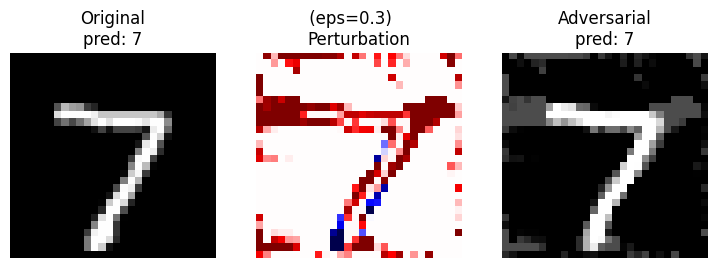

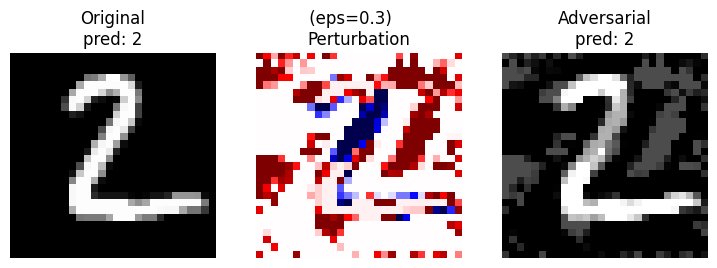

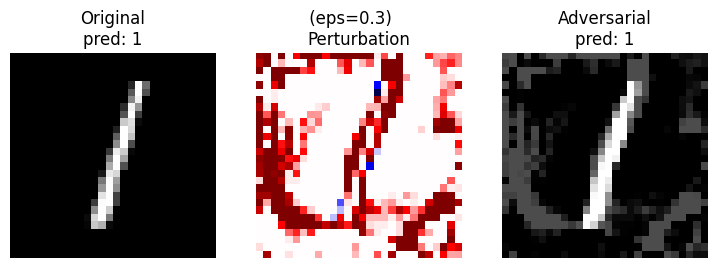

In [10]:
print("Visualizing attacks on CNN...")
visualize_attack(basic_cnn, data.test, attack=pgd_attack, eps=0.3, n_samples=3) # or fgsm_attack

Visualizing attacks on CNN...


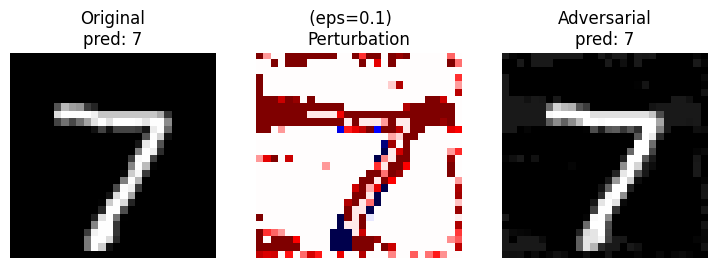

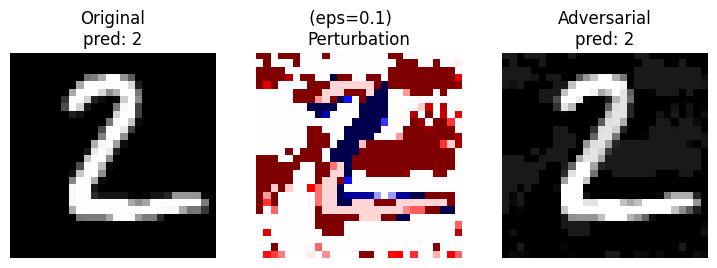

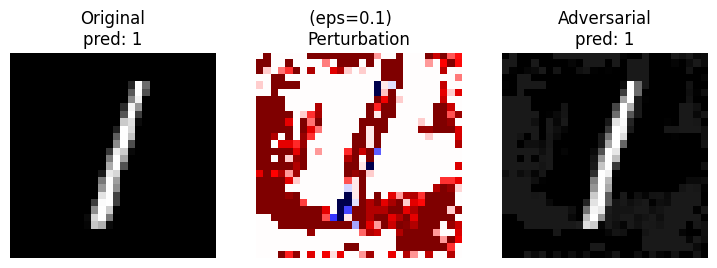

In [11]:
print("Visualizing attacks on CNN...")
visualize_attack(basic_cnn, data.test, attack=pgd_attack, eps=0.1, n_samples=3) 

Visualizing attacks on CNN...


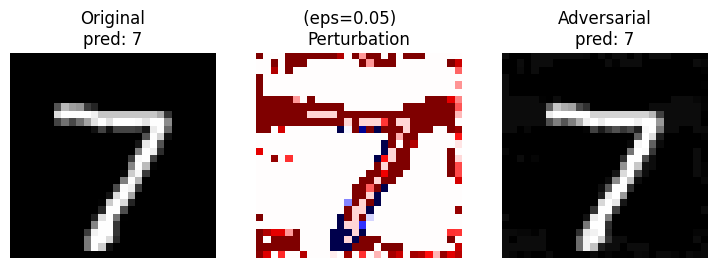

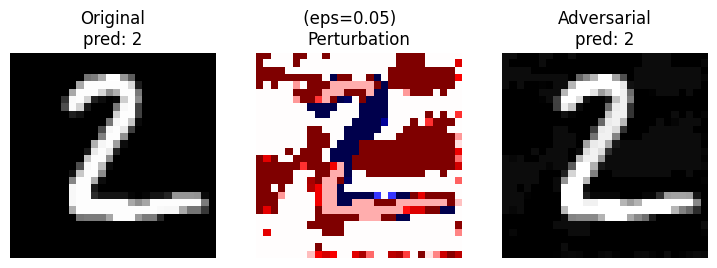

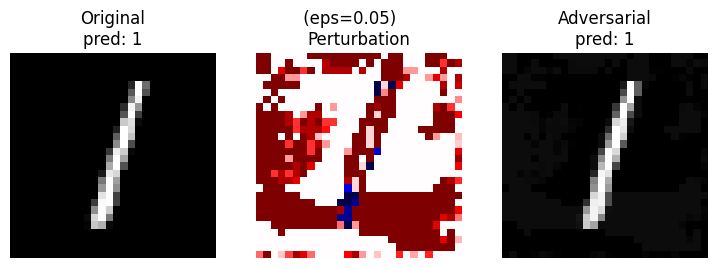

In [12]:
print("Visualizing attacks on CNN...")
visualize_attack(basic_cnn, data.test, attack=pgd_attack, eps=0.05, n_samples=3) 

In [16]:
# Code in this cell was written using LLMs
def pgd_fool_rate(model, loader, eps=0.3, eps_iter=0.01, nb_iter=40, max_batches=8):
    """Share of labels flipped by PGD, on a few test batches."""
    model.eval()
    fooled, total = 0, 0
    for i, (x, y) in enumerate(loader):
        if i >= max_batches:
            break
        adv, _ = pgd_attack(model, x, y, eps=eps, eps_iter=eps_iter, nb_iter=nb_iter)
        fooled += (model(adv).argmax(1) != y).sum().item()
        total += y.size(0)
    return 100.0 * fooled / total

print("clean error (no attack):", f"{100 - evaluate_model(basic_cnn, data.test):.2f}%")
print("default  eps_iter=0.01, nb_iter=40 ->", f"{pgd_fool_rate(basic_cnn, data.test):.1f}%")
print("too few steps  nb_iter=1          ->", f"{pgd_fool_rate(basic_cnn, data.test, nb_iter=1):.1f}%")
print("tiny steps     eps_iter=1e-4      ->", f"{pgd_fool_rate(basic_cnn, data.test, eps_iter=1e-4):.1f}%")
print("max step size  eps_iter=eps=0.3   ->", f"{pgd_fool_rate(basic_cnn, data.test, eps_iter=0.3):.1f}%")


clean error (no attack): 1.88%
default  eps_iter=0.01, nb_iter=40 -> 99.6%
too few steps  nb_iter=1          -> 4.1%
tiny steps     eps_iter=1e-4      -> 3.2%
max step size  eps_iter=eps=0.3   -> 99.6%


### Questions

1. At what level of perturbation (epsilon) does it become difficult for us humans to see it?
2. What does `eps_iter` and `nb_iter` in the projected gradient descent attack do? At what values does the attack not work anymore? Why?

### Answers

1.  At 0.3 and 0.1 it is quite clear that there is noise in the "background" around the image. When we lower it to 0.5 it is barely susceptible, but you are able to see it if you squint and know what you are looking for.
On the other hand, non of the attacks are succesfull in pertubating towards a different prediction than the golden label.

2. nb_iter is how many PGD steps. eps_iter is the step size (then clipped back into the $\epsilon$-box). Too few or too small steps (`nb_iter=1` or `eps_iter=1e-4`) barely move the image, so error stays near the clean error rate. When eps_iter is large, it mimmicks the behavior of FGSM.

# Poison Attack

Let's try a poisoning attack, which occurs during the training phase. We will specifically try a targeted and untargeted attack by flipping the labels of training examples.

**Uniform:**  
In a uniform attack the goal is to make the model misidentify an example as any other label. This type of attack is used to lower the performance of the model and reduces the normal functionality for users.   

$$(x, y) \mapsto (x, y'), \quad y' \sim \text{Unif}\big(\{c \in \mathcal{Y} : c \neq y\}\big)$$

**Targeted:**  
In a targeted attack the goal is to make the model misidentify an example as a specific label. This type of attack is used to avoid detection while aiming to preserve performance on other inputs. In this case we are only classifying 10 digits, but consider an object detection model has over 1000 classes, a targeted attack could affect a rare class while aiming to preserve the performance of the normal system operation.

$$(x, s) \mapsto (x, t), \qquad s \neq t$$

### Setting up the poison attacks

We will go with a `flip_rate=0.05`, meaning that `5%` of labels are flipped to other classes.

By experimenting with the `flip_rate`, we can see how few of the examples need to be "poisoned" in order to diminish the models accuracy. Flipping `5%` of uniform labels flips `5%` of the dataset while `5%` of targeted label flipping only flips around 0.5% overall.

In [ ]:
class PoisonedLabels(Dataset):
    def __init__(self, dataset, method="uniform", frac=0.05, seed=None, n_classes=10, source_class=None, target_class=None):
        """
        Wraps existing dataset and poisons labels using different strategies.

        Args:
            dataset: base dataset (e.g., torchvision.datasets.MNIST)
            method: "uniform" or "targeted"
            frac: fraction of labels to flip
            seed: random seed for reproducibility
            n_classes: number of classes (default=10 for MNIST)
            source_class: class to flip label from
            target_class: class to flip label to
        """
        self.dataset = dataset
        self.method = method
        self.frac = frac
        self.n_classes = n_classes
        self.rng = np.random.default_rng(seed)
        self.source_class = source_class
        self.target_class = target_class

        # extract labels
        if hasattr(dataset, "targets"):
            y = np.array(dataset.targets)
        elif hasattr(dataset, "labels"):
            y = np.array(dataset.labels)
        else:
            raise AttributeError("dataset has no targets or labels attribute")

        # choose poisoning method
        if method == "uniform":
            y_poison, flip_idx = self._poison_uniform(y)
        elif method == "targeted":
            y_poison, flip_idx = self._poison_targeted(y)
        else:
            raise ValueError(f"Unknown poisoning method: {method}")

        self.targets = y_poison.tolist()
        self.flip_idx = flip_idx  # store indices that were flipped

    def _poison_uniform(self, y):
        """Flip a fraction of labels to a *different* class."""
        n = len(y)
        n_flips = int(self.frac * n)
        flip_idx = self.rng.choice(n, size=n_flips, replace=False)

        y_flipped = y.copy()
        for i in flip_idx:
            new_label = self.rng.integers(0, self.n_classes)
            while new_label == y_flipped[i]:
                new_label = self.rng.integers(0, self.n_classes)
            y_flipped[i] = new_label
        return y_flipped, flip_idx

    def _poison_targeted(self, y):
        """Flip a fraction of one class's labels to a chosen target class."""
        if self.source_class == self.target_class:
            raise ValueError("source_class and target_class must be different")
        if self.source_class == None or self.target_class == None:
            raise ValueError("targeted poisoning requires source and target classes")        

        candidates = np.flatnonzero(y == self.source_class)
        n_flips = int(self.frac * len(candidates))
        flip_idx = self.rng.choice(candidates, size = n_flips, replace=False)

        y_flipped = y.copy()
        y_flipped[flip_idx] = self.target_class
        return y_flipped, flip_idx 

    def __getitem__(self, idx):
        x, _ = self.dataset[idx]
        return x, self.targets[idx]

    def __len__(self):
        return len(self.dataset)


## Training of the Poison Models

The following code poisons the training data by flipping 5% of the labels to another class in order to misclassify them, then the model is retrained on the poisoned data.

We recommend to use the basic CNN model to retrain as it is slightly quicker in training than the other model.

In [ ]:
# testing clean model
base_acc_ = evaluate_model(basic_cnn, data.test)
print(f"Test Accuracy (Basic CNN): {base_acc_:.2f}%")

Test Accuracy (Basic CNN): 98.12%


In [ ]:
# Apply poisoning
poisoned_dataset = PoisonedLabels(data.train.dataset, method="uniform", frac=0.20, seed=42, source_class=0, target_class=1)
poisoned_train_loader = torch.utils.data.DataLoader(poisoned_dataset, batch_size=128, shuffle=True)

# training poisoned model
model_to_poison = Basic_CNN()
poisoned_model = train_model(model_to_poison, poisoned_train_loader, data.test, epochs=1)
poisoned_acc_ = evaluate_model(poisoned_model, data.test)

Epoch 1/1: 100%|██████████| 469/469 [01:30<00:00,  5.19it/s]

Epoch 1: Loss = 1.1231


Test Accuracy after epoch 1: 97.67%


In [ ]:
torch.save(poisoned_model.state_dict(), "basic_cnn_poisoned_0_20.pth")
print(f"Test Accuracy (Basic CNN): {base_acc_:.2f}%")
print(f"Test Accuracy (Poisoned Model): {poisoned_acc_:.2f}%")

Test Accuracy (Basic CNN): 98.12%
Test Accuracy (Poisoned Model): 97.67%


In [ ]:
# Apply poisoning
poisoned_dataset = PoisonedLabels(data.train.dataset, method="uniform", frac=0.05, seed=42, source_class=0, target_class=1)
poisoned_train_loader = torch.utils.data.DataLoader(poisoned_dataset, batch_size=128, shuffle=True)

# training poisoned model
model_to_poison = Basic_CNN()
poisoned_model = train_model(model_to_poison, poisoned_train_loader, data.test, epochs=1)
poisoned_acc_ = evaluate_model(poisoned_model, data.test)

# Save and eval
torch.save(poisoned_model.state_dict(), "basic_cnn_poisoned_0_05.pth")
print(f"Test Accuracy (Basic CNN): {base_acc_:.2f}%")
print(f"Test Accuracy (Poisoned Model): {poisoned_acc_:.2f}%")

Epoch 1/1: 100%|██████████| 469/469 [01:35<00:00,  4.90it/s]

Epoch 1: Loss = 0.4982


Test Accuracy after epoch 1: 98.47%
Test Accuracy (Basic CNN): 98.12%
Test Accuracy (Poisoned Model): 98.47%


In [ ]:
# Apply poisoning
poisoned_dataset = PoisonedLabels(data.train.dataset, method="uniform", frac=0.50, seed=42, source_class=0, target_class=1)
poisoned_train_loader = torch.utils.data.DataLoader(poisoned_dataset, batch_size=128, shuffle=True)

# training poisoned model
model_to_poison = Basic_CNN()
poisoned_model = train_model(model_to_poison, poisoned_train_loader, data.test, epochs=1)
poisoned_acc_ = evaluate_model(poisoned_model, data.test)

# Save and eval
torch.save(poisoned_model.state_dict(), "basic_cnn_poisoned_0_50.pth")
print(f"Test Accuracy (Basic CNN): {base_acc_:.2f}%")
print(f"Test Accuracy (Poisoned Model): {poisoned_acc_:.2f}%")

Epoch 1/1: 100%|██████████| 469/469 [01:30<00:00,  5.17it/s]

Epoch 1: Loss = 1.9056


Test Accuracy after epoch 1: 97.18%
Test Accuracy (Basic CNN): 98.12%
Test Accuracy (Poisoned Model): 97.18%


In [ ]:
# Apply poisoning
poisoned_dataset = PoisonedLabels(data.train.dataset, method="targeted", frac=0.50, seed=42, source_class=0, target_class=1)
poisoned_train_loader = torch.utils.data.DataLoader(poisoned_dataset, batch_size=128, shuffle=True)

# training poisoned model
model_to_poison = Basic_CNN()
poisoned_model = train_model(model_to_poison, poisoned_train_loader, data.test, epochs=1)
poisoned_acc_ = evaluate_model(poisoned_model, data.test)

Epoch 1/1: 100%|██████████| 469/469 [01:33<00:00,  5.00it/s]

Epoch 1: Loss = 0.2348


Test Accuracy after epoch 1: 89.20%


In [ ]:
# Save and eval
torch.save(poisoned_model.state_dict(), "basic_cnn_poisoned_targeted_0_50.pth")
print(f"Test Accuracy (Basic CNN): {base_acc_:.2f}%")
print(f"Test Accuracy (Poisoned Model): {poisoned_acc_:.2f}%")

Test Accuracy (Basic CNN): 98.12%
Test Accuracy (Poisoned Model): 89.20%


In [ ]:
# Apply poisoning
poisoned_dataset = PoisonedLabels(data.train.dataset, method="targeted", frac=0.20, seed=42, source_class=0, target_class=1)
poisoned_train_loader = torch.utils.data.DataLoader(poisoned_dataset, batch_size=128, shuffle=True)

# training poisoned model
model_to_poison = Basic_CNN()
poisoned_model = train_model(model_to_poison, poisoned_train_loader, data.test, epochs=1)
poisoned_acc_ = evaluate_model(poisoned_model, data.test)

# Save and eval
torch.save(poisoned_model.state_dict(), "basic_cnn_poisoned_targeted_0_20.pth")
print(f"Test Accuracy (Basic CNN): {base_acc_:.2f}%")
print(f"Test Accuracy (Poisoned Model): {poisoned_acc_:.2f}%")

Epoch 1/1: 100%|██████████| 469/469 [01:33<00:00,  5.02it/s]

Epoch 1: Loss = 0.2115


Test Accuracy after epoch 1: 98.27%
Test Accuracy (Basic CNN): 98.12%
Test Accuracy (Poisoned Model): 98.27%


In [ ]:
# Apply poisoning
poisoned_dataset = PoisonedLabels(data.train.dataset, method="targeted", frac=0.05, seed=42, source_class=0, target_class=1)
poisoned_train_loader = torch.utils.data.DataLoader(poisoned_dataset, batch_size=128, shuffle=True)

# training poisoned model
model_to_poison = Basic_CNN()
poisoned_model = train_model(model_to_poison, poisoned_train_loader, data.test, epochs=1)
poisoned_acc_ = evaluate_model(poisoned_model, data.test)

# Save and eval
torch.save(poisoned_model.state_dict(), "basic_cnn_poisoned_targeted_0_05.pth")
print(f"Test Accuracy (Basic CNN): {base_acc_:.2f}%")
print(f"Test Accuracy (Poisoned Model): {poisoned_acc_:.2f}%")

Epoch 1/1: 100%|██████████| 469/469 [01:27<00:00,  5.37it/s]

Epoch 1: Loss = 0.1898


Test Accuracy after epoch 1: 98.41%
Test Accuracy (Basic CNN): 98.12%
Test Accuracy (Poisoned Model): 98.41%


## Questions

1. Can you think of reasons for why it fails at that low percentage, model complexity, data size etc.
2. Do you see any difference in the amount needed from each of the two poisoning approaches?
3. Which of the two methods violate integrity and which one violates availability?
4. Other poisoning methods you can think of that might be more effective?
5. How do overall accuracy and targeted misclassification change as the poisoning rate increases?

## Answers

1. Random label flips may not create enough of a noisy signal for the model to learn it - it might be perceived as an outlier in a population of another class and therefore not be learned for the generalized case. Also, random flips may cancel each other out by pulling the gradient in opposing directions. In particular, we see that at 0.05 with uniform flipping, the model even improved!
2. Somehow the targeted approach makes the model better on the test set in two of the chosen levels (5% and 20%) and then drops SIGNIFICANTLY at the level of 50% (to way below the uniform approach). On the other hand, the uniform approach simply decreases little by little to worse performance with no significant drop.
3. The targeted approach violates integrity because it makes the model make wrong predictions on a target class. The uniform approach violated availability, because it is degrading the performance and therefore general useability of the model. 
4. Maybe perturbing the images that we train on, such that they are noisy and therefore induces instabilities. Especially if we can make such minor perturbations that is hard to detect in feature spaces and by manual inspection -> f.ex. perturbing 1s to look like 7s, are close in feature space.
5. In the uniform case, test accuracy falls slowly at first (while the vast majority are still valid samples) and the accuracy becomes worse and worse (which makes sense when less and less samples are representing their actual class).
In the targeted case the model performs similar to the baseline for the two lower poisoning rates and drops significantly for the high poisoning rate. We see that this model is slightly more succesfull in making the model misclassify the target class, even when only poisoning 5% of samples the misclassification is increased from 0.2% -> 0.51%, and at 20% poisoning is increased to 1.63% misclassification, while still being undetected in the overall accuracy.


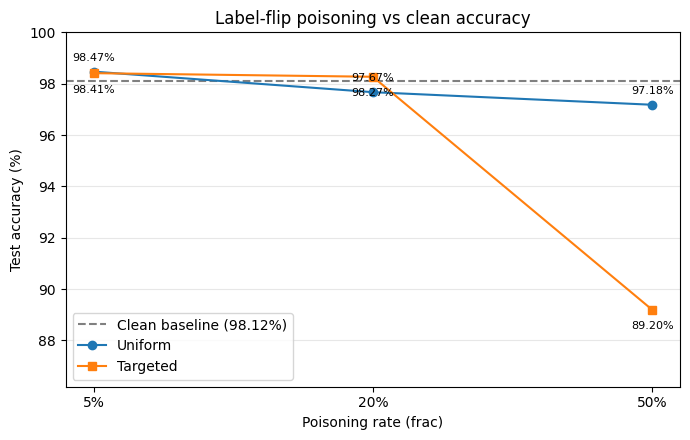

Clean 0→1 rate: 0.20%
Uniform 0→1: {0.05: '0.10%', 0.2: '0.10%', 0.5: '0.10%'}
Targeted 0→1: {0.05: '0.51%', 0.2: '1.63%', 0.5: '96.33%'}


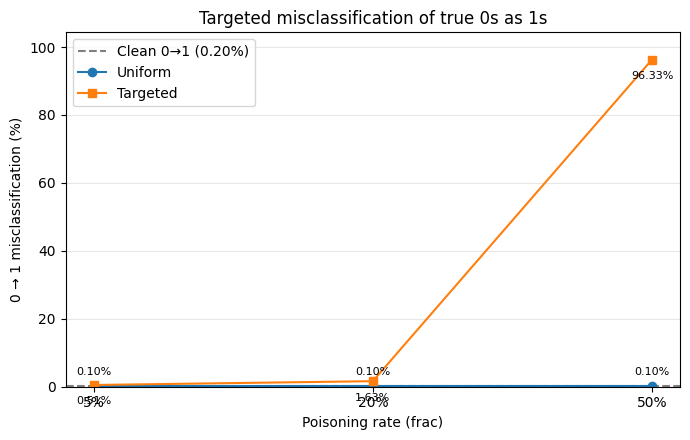

In [ ]:
## Code in this cell was generated with the help of Cursor,
## in order to fulfill certain goals of visualizing metrics of the poisoned
## models. the above text and conclusions were made by me without use of LLM.
BASELINE = base_acc_
UNIFORM = {0.05: 0.9847, 0.2: 0.9767, 0.50: 0.9718}
TARGETED = {0.5: 0.8920, 0.2: 0.9827, 0.05: 0.9841}

def as_pct(x):
    return x * 100.0 if x <= 1 else float(x)

rates = sorted(set(UNIFORM) | set(TARGETED))
baseline_pct = as_pct(BASELINE)
uniform_pct = [as_pct(UNIFORM[r]) for r in rates]
targeted_pct = [as_pct(TARGETED[r]) for r in rates]
rate_labels = [f"{int(r * 100)}%" for r in rates]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.axhline(baseline_pct, color="gray", linestyle="--", linewidth=1.5, label=f"Clean baseline ({baseline_pct:.2f}%)")
ax.plot(rate_labels, uniform_pct, marker="o", label="Uniform")
ax.plot(rate_labels, targeted_pct, marker="s", label="Targeted")
for x, y in zip(rate_labels, uniform_pct):
    ax.annotate(f"{y:.2f}%", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
for x, y in zip(rate_labels, targeted_pct):
    ax.annotate(f"{y:.2f}%", (x, y), textcoords="offset points", xytext=(0, -14), ha="center", fontsize=8)
ax.set_xlabel("Poisoning rate (frac)")
ax.set_ylabel("Test accuracy (%)")
ax.set_title("Label-flip poisoning vs clean accuracy")
ax.set_ylim(min(targeted_pct + uniform_pct + [baseline_pct]) - 3, 100)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

SOURCE, TARGET = 0, 1

def source_to_target_rate(model, loader, source=SOURCE, target=TARGET, device="cpu"):
    """Share of true `source` examples predicted as `target`."""
    model.eval()
    n_source = 0
    n_src_to_tgt = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            pred = model(images).argmax(1)
            is_source = labels == source
            n_source += is_source.sum().item()
            n_src_to_tgt += ((pred == target) & is_source).sum().item()
    return 100.0 * n_src_to_tgt / n_source if n_source else 0.0

def load_basic_cnn(path):
    model = Basic_CNN()
    model.load_state_dict(torch.load(path, map_location="cpu"))
    return model

UNIFORM_CKPTS = {
    0.05: "basic_cnn_poisoned_0_05.pth",
    0.20: "basic_cnn_poisoned_0_20.pth",
    0.50: "basic_cnn_poisoned_0_50.pth",
}
TARGETED_CKPTS = {
    0.05: "basic_cnn_poisoned_targeted_0_05.pth",
    0.20: "basic_cnn_poisoned_targeted_0_20.pth",
    0.50: "basic_cnn_poisoned_targeted_0_50.pth",
}

baseline_mis = source_to_target_rate(basic_cnn, data.test)
UNIFORM_MIS = {r: source_to_target_rate(load_basic_cnn(p), data.test) for r, p in UNIFORM_CKPTS.items()}
TARGETED_MIS = {r: source_to_target_rate(load_basic_cnn(p), data.test) for r, p in TARGETED_CKPTS.items()}
print(f"Clean 0→1 rate: {baseline_mis:.2f}%")
print("Uniform 0→1:", {r: f"{v:.2f}%" for r, v in UNIFORM_MIS.items()})
print("Targeted 0→1:", {r: f"{v:.2f}%" for r, v in TARGETED_MIS.items()})

uniform_mis = [UNIFORM_MIS[r] for r in rates]
targeted_mis = [TARGETED_MIS[r] for r in rates]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.axhline(baseline_mis, color="gray", linestyle="--", linewidth=1.5, label=f"Clean 0→1 ({baseline_mis:.2f}%)")
ax.plot(rate_labels, uniform_mis, marker="o", label="Uniform")
ax.plot(rate_labels, targeted_mis, marker="s", label="Targeted")
for x, y in zip(rate_labels, uniform_mis):
    ax.annotate(f"{y:.2f}%", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
for x, y in zip(rate_labels, targeted_mis):
    ax.annotate(f"{y:.2f}%", (x, y), textcoords="offset points", xytext=(0, -14), ha="center", fontsize=8)
ax.set_xlabel("Poisoning rate (frac)")
ax.set_ylabel("0 → 1 misclassification (%)")
ax.set_title("Targeted misclassification of true 0s as 1s")
ax.set_ylim(0, max(targeted_mis + uniform_mis + [baseline_mis]) + 8)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# Whitebox attack / Surrogate transferability

It has been noticed early on in the field that adversarial attacks actually transfer across neural networks. For instance, the research paper [Why Do Adversarial Attacks Transfer? Explaining Transferability of Evasion and Poisoning Attacks](https://www.usenix.org/system/files/sec19-demontis.pdf).

The idea is that we could craft an adversarial attack on a local **surrogate model** and still successfully carry out the same attack on a **target model**.

While the target model might be black-box, we can use our surrogate model as a white-box for gradient descent.


In [ ]:
data = ld_mnist()
print("Data loaded.")

Data loaded.


## Surrogate CNN

Let's train our attack on the `BasicCNN`.

In [ ]:
# If data.train is a DataLoader, get its underlying dataset
train_dataset = data.train.dataset if hasattr(data.train, "dataset") else data.train
test_loader = data.test  # assuming this is already a DataLoader
Train_model_surrogate = False

if not os.path.exists("surrogate_20_model.pth") or not os.path.exists("surrogate_regularized_model.pth"):
    Train_model_surrogate = True

if Train_model_surrogate:
    # (a) Only 20% of training data
    subset_size = int(0.2 * len(train_dataset))
    subset, _ = torch.utils.data.random_split(train_dataset, [subset_size, len(train_dataset)-subset_size])
    surrogate_loader_small = torch.utils.data.DataLoader(subset, batch_size=128, shuffle=True)

    surrogate_20_model = Basic_CNN()
    surrogate_20_model = train_model(surrogate_20_model, surrogate_loader_small, test_loader, epochs=1)
    print(f"Surrogate (20% data) acc: {evaluate_model(surrogate_20_model, test_loader)}%")

    # (b) Stronger regularization
    surrogate_regularized_model = Basic_CNN(p_drop=0.5)
    surrogate_regularized_model = train_model(surrogate_regularized_model, data.train, test_loader, epochs=1)
    print(f"Surrogate (regularized) acc: {evaluate_model(surrogate_regularized_model, test_loader)}%")

    # Save models
    torch.save(surrogate_20_model.state_dict(), "surrogate_20_model.pth")
    torch.save(surrogate_regularized_model.state_dict(), "surrogate_regularized_model.pth")
else:
    surrogate_20_model = Basic_CNN()
    surrogate_20_model.load_state_dict(torch.load("surrogate_20_model.pth", map_location="cpu"))
    surrogate_regularized_model = Basic_CNN(p_drop=0.5)
    surrogate_regularized_model.load_state_dict(torch.load("surrogate_regularized_model.pth", map_location="cpu"))


The test accuracies achieved from these models are the surrogate models accuracies on the clean test set. The real test comes in the next section where we use these surrogates to generate new attack data to fool the big or Target CNN.

## Transfer

Now we are ready to transfer the adversarial examples to the target model.

In [ ]:
def transfer_attack(surrogate, target, loader, eps=0.3):
    device = "cpu"
    surrogate.eval(); target.eval()
    total, fooled_sur, fooled_tgt = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        # adversarial crafted on surrogate
        x_adv, _ = fgsm_attack(surrogate, x, y, eps=eps)
        # predictions
        pred_sur = surrogate(x_adv).argmax(1)
        pred_tgt = target(x_adv).argmax(1)
        # fooling stats
        fooled_sur += (pred_sur != y).sum().item()
        fooled_tgt += (pred_tgt != y).sum().item()
        total += y.size(0)
    return fooled_sur/total, fooled_tgt/total

rate_sur, rate_tgt = transfer_attack(surrogate_20_model, target_cnn, data.test)
print(f"Transfer (20% surrogate) Surrogate adversarial error: {rate_sur*100:.2f}%,\n Target adversarial error: {rate_tgt*100:.2f}%")
print("---")
rate_sur, rate_tgt = transfer_attack(surrogate_regularized_model, target_cnn, data.test)
print(f"Transfer (regularized surrogate) Surrogate adversarial error: {rate_sur*100:.2f}%,\n Target adversarial error: {rate_tgt*100:.2f}%")

Transfer (20% surrogate) Surrogate adversarial error: 96.61%,
 Target adversarial error: 86.85%
---
Transfer (regularized surrogate) Surrogate adversarial error: 93.86%,
 Target adversarial error: 86.97%


In [ ]:
rate_sur, rate_tgt = transfer_attack(surrogate_20_model, target_cnn, data.test, eps=0.5)
print(f"Transfer (20% surrogate) Surrogate adversarial error: {rate_sur*100:.2f}%,\n Target adversarial error: {rate_tgt*100:.2f}%")
print("---")
rate_sur, rate_tgt = transfer_attack(surrogate_regularized_model, target_cnn, data.test, eps=0.5)
print(f"Transfer (regularized surrogate) Surrogate adversarial error: {rate_sur*100:.2f}%,\n Target adversarial error: {rate_tgt*100:.2f}%")

Transfer (20% surrogate) Surrogate adversarial error: 99.95%,
 Target adversarial error: 98.57%
---
Transfer (regularized surrogate) Surrogate adversarial error: 99.19%,
 Target adversarial error: 98.68%


In [ ]:
rate_sur, rate_tgt = transfer_attack(surrogate_20_model, target_cnn, data.test, eps=0.05)
print(f"Transfer (20% surrogate) Surrogate adversarial error: {rate_sur*100:.2f}%,\n Target adversarial error: {rate_tgt*100:.2f}%")
print("---")
rate_sur, rate_tgt = transfer_attack(surrogate_regularized_model, target_cnn, data.test, eps=0.05)
print(f"Transfer (regularized surrogate) Surrogate adversarial error: {rate_sur*100:.2f}%,\n Target adversarial error: {rate_tgt*100:.2f}%")

Transfer (20% surrogate) Surrogate adversarial error: 11.01%,
 Target adversarial error: 5.56%
---
Transfer (regularized surrogate) Surrogate adversarial error: 4.62%,
 Target adversarial error: 5.76%


The results from here show how well the surrogate models themselves were at classifying the examples generated and the Target models own classification compared.

### Questions:
- How does surrogate regularization affect attack transferability?
- How much surrogate training data is needed to have an effective transfer?

### Answers:
- The surrogate model is more often fooled. The regularization in the surrogate model has a big effect in reducing the error rate, but for the target model that is not the case in our experiment - they have very similar error rates on the target model.
- At 20% it is already quite severe at both $\epsilon = 0.3$ & $\epsilon = 0.5$ - it may be possible to gain the same effect with less data :D At $\epsilon = 0.05$ we may need quite a bit of data to see a severe reaction.

# Exercises

<!-- todo -->

##### Exercise 1 – Evasion on FashionMNIST  
Train a CNN on the FashionMNIST dataset (you may adjust its complexity). Complete the implementation of FGSM and PGD to generate adversarial examples against this model and visualize both the clean and perturbed images to see how small the changes look.

### Template code to begin with FashionMNIST

In [19]:
def ld_mnistFashion():
    train_transforms = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])
    test_transforms = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])

    # Load MNISTFashion dataset
    train_dataset = torchvision.datasets.FashionMNIST(root="/tmp/data", train = True, download = True, transform=train_transforms)
    test_dataset = torchvision.datasets.FashionMNIST(root="/tmp/data", train=False, download = True, transform=test_transforms)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)
    
    return EasyDict(train=train_loader, test=test_loader)


ld_mnistFashion()
dataFashion = ld_mnistFashion()
print("Data loaded.")

Data loaded.


In [20]:
fashion_cnn = Basic_CNN()

if not os.path.exists("fashion_cnn.pth"):
    fashion_cnn = train_model(fashion_cnn, dataFashion.train, dataFashion.test, epochs=1)
    torch.save(fashion_cnn.state_dict(), "fashion_cnn.pth")
else:
    fashion_cnn.load_state_dict(torch.load("fashion_cnn.pth", map_location="cpu"))
    fashion_cnn.eval()

In [23]:
def fgsm_attack_todo(model, x, y, eps=0.3, norm=np.inf):
    "Untargeted L-inf FGSM"
    if norm != np.inf:
        raise ValueError("Only supports inf norm")
    if eps<0:
        raise ValueError("eps must be non-negative.")

    model.eval()
    x = x.detach().clone().requires_grad_(True)

    # Differentiate the loss w.r.t. the input pixels
    loss = F.cross_entropy(model(x), y)
    grad = torch.autograd.grad(loss, x)[0]

    # Take one step that increases the loss
    adv = (x + eps * torch.sign(grad)).clamp(0.0, 1.0) # clamp inside pixel value range
    delta = adv - x
    return adv.detach(), delta.detach()

def pgd_attack_todo(model, x, y, eps=0.3, norm=np.inf):
    "Untargeted L-inf PGD"
    if norm != np.inf:
        raise ValueError("This sign-gradient implementation supports only norm=np.inf.")
    if eps < 0:
        raise ValueError("eps must be non-negative.")

    model.eval()
    x = x.detach()
    eps_iter = 0.01
    nb_iter = 40

    # Random start inside the epsilon range
    adv = (x + torch.empty_like(x).uniform_(-eps, eps)).clamp(0.0, 1.0)

    for _ in range(nb_iter):
        # Recompute the input gradient at the current adversarial image.
        adv = adv.detach().requires_grad_(True)
        loss = F.cross_entropy(model(adv), y)
        grad = torch.autograd.grad(loss, adv)[0]

        # Take a small step that increases the loss.
        # change the latest adv sample by step of size eps_iter in the direction of the gradient
        adv = (adv + eps_iter * torch.sign(grad)) # clamped into valid pixel values later

        # Project back into the epsilon box, then keep valid pixel values.
        delta = (adv - x).clamp(-eps, eps)
        adv = (x + delta).clamp(0.0, 1.0)

    delta = adv - x
    return adv.detach(), delta.detach()

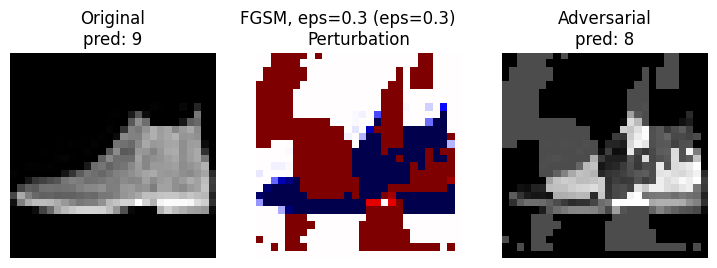

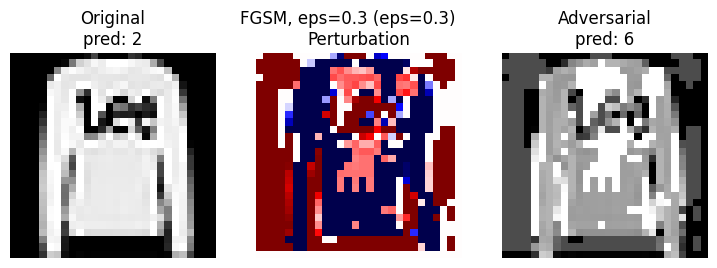

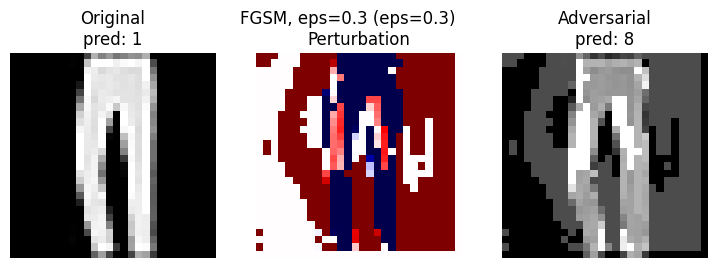

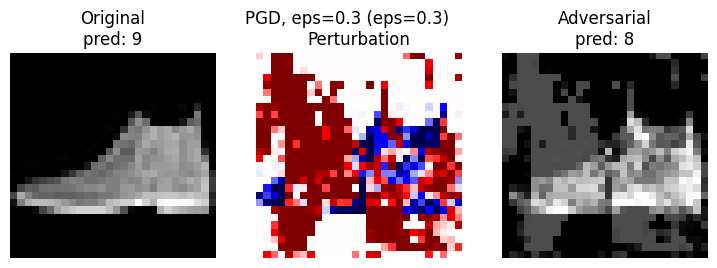

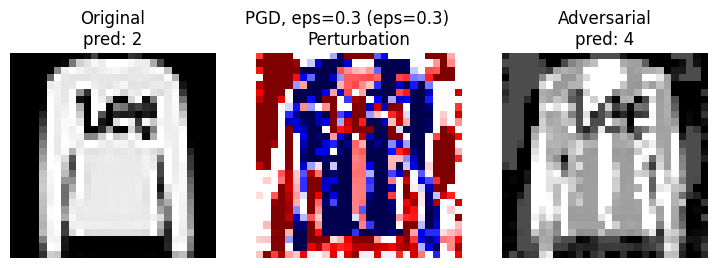

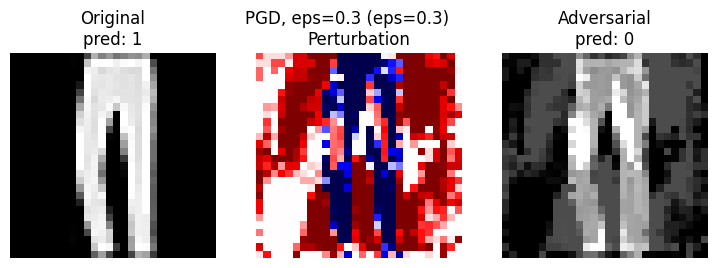

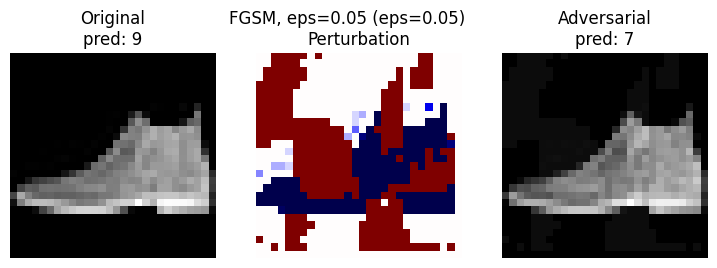

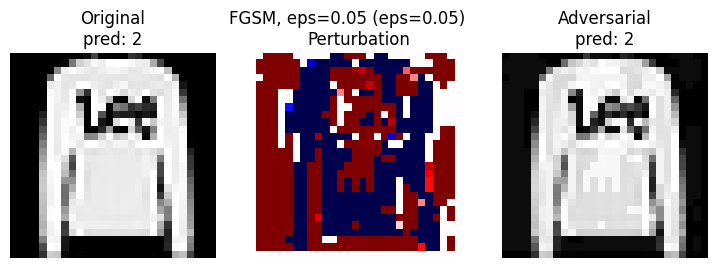

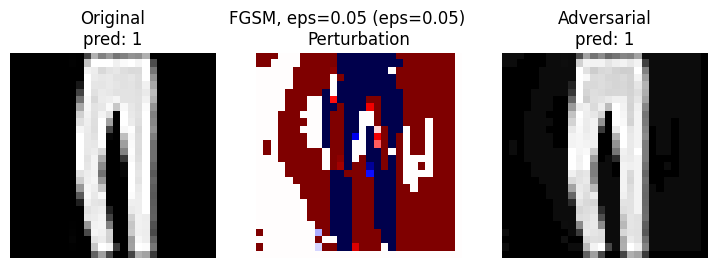

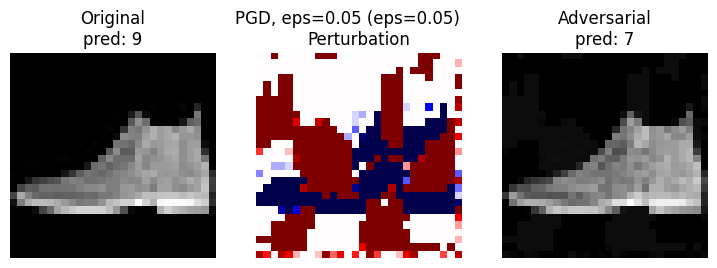

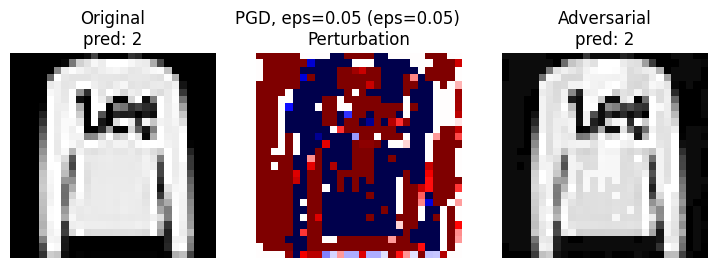

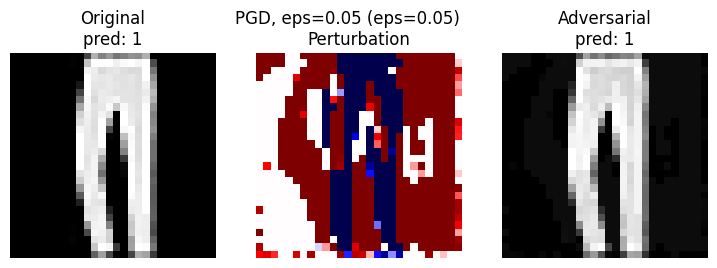

In [24]:
# Same helper as earlier: original | perturbation | adversarial
visualize_attack(fashion_cnn, dataFashion.test, attack=fgsm_attack_todo, eps=0.3, n_samples=3, title="FGSM, eps=0.3")
visualize_attack(fashion_cnn, dataFashion.test, attack=pgd_attack_todo, eps=0.3, n_samples=3, title="PGD, eps=0.3")
visualize_attack(fashion_cnn, dataFashion.test, attack=fgsm_attack_todo, eps=0.05, n_samples=3, title="FGSM, eps=0.05")
visualize_attack(fashion_cnn, dataFashion.test, attack=pgd_attack_todo, eps=0.05, n_samples=3, title="PGD, eps=0.05")


#### Exercise 2 – Poisoning the Model  
Apply poisoning techniques like label flip to the same CNN (uniform and targeted). Retrain the model with poisoned data and evaluate how the attack affects overall accuracy and targeted misclassification.

In [ ]:
# To-do

#### Exercise 3 – Transferability with a Surrogate  
Train a second, surrogate CNN with a different architecture or complexity. Craft adversarial or poisoned examples on the surrogate and then test them against the original (primary) model to measure how well the attacks transfer across models.

In [ ]:
# To-do